In [117]:
import os
import json
from collections import defaultdict
from pathlib import Path
from pprint import pprint
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

DIRPATH_ROOT = Path().resolve().parents[1]
dirpath_self = Path().resolve()
sys.path.append(str(DIRPATH_ROOT))
sys.path.append(str(dirpath_self))
print(DIRPATH_ROOT)
print(dirpath_self)

D:\WORK\Salvador\repo\A1_OUinp
D:\WORK\Salvador\repo\A1_OUinp\analysis\model_utils


In [118]:
fpath_conn = DIRPATH_ROOT / 'conn' / 'conn.nc'
C = xr.load_dataset(fpath_conn)
C

<xarray.Dataset>
Dimensions:   (pop_post: 43, pop_pre: 43)
Coordinates:
  * pop_post  (pop_post) object 'IT2' 'IT3' 'ITP4' 'ITS4' ... 'IREM' 'TI' 'TIM'
  * pop_pre   (pop_pre) object 'IT2' 'IT3' 'ITP4' 'ITS4' ... 'IREM' 'TI' 'TIM'
Data variables:
    pmat      (pop_post, pop_pre) float64 0.1971 0.1971 0.1725 ... 0.3 nan 0.53
    wmat      (pop_post, pop_pre) float64 0.36 0.36 0.78 0.78 ... 0.5 nan 0.5
    N         (pop_pre) int32 338 4461 837 837 359 359 ... 155 38 155 155 51 51
    r         (pop_pre) float64 2.0 2.0 2.0 2.0 5.0 ... 8.0 15.0 10.0 15.0 10.0

In [1]:

def _to_list(x):
    if x is None:
        return []
    if np.isscalar(x):
        return [x]
    return list(x)


def plot_mat(ax, da, title, sep_x=None, sep_y=None, transpose=True, yinv=True):
    if transpose:
        da = da.transpose('pop_post', 'pop_pre')
    else:
        da = da.transpose('pop_pre', 'pop_post')
    vmax = float(np.nanmax(np.abs(da.values)))
    im = ax.imshow(da.values, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    plt.colorbar(im, ax=ax, label=title)
    if yinv:
        ax.invert_yaxis()

    pops_post = list(da.pop_post.values)
    pops_pre = list(da.pop_pre.values)

    if transpose:
        pops_x = pops_pre
        pops_y = pops_post
        ax.set_xlabel('Pre')
        ax.set_ylabel('Post')
    else:
        pops_x = pops_post
        pops_y = pops_pre
        ax.set_xlabel('Post')
        ax.set_ylabel('Pre')

    ax.set_xticks(range(len(pops_x)))
    ax.set_xticklabels(pops_x, rotation=45, ha='right')
    ax.set_yticks(range(len(pops_y)))
    ax.set_yticklabels(pops_y)

    ax.set_title(title)

    for sep_x_ in _to_list(sep_x):
        ax.axvline(x=sep_x_ - 0.5, color='k', lw=2)
    for sep_y_ in _to_list(sep_y):
        ax.axhline(y=sep_y_ - 0.5, color='k', lw=2)


def plot_conn(pops_pre=None, pops_post=None, pops_inh=None,
              sep_x=None, sep_y=None, transpose=True, yinv=True):
    if pops_pre is None:
        pops_pre = C['pop_pre'].values
    if pops_post is None:
        pops_post = C['pop_post'].values
    pmat = C['pmat'].sel(pop_post=pops_post, pop_pre=pops_pre)
    wmat = C['wmat'].sel(pop_post=pops_post, pop_pre=pops_pre)
    N = C['N'].sel(pop_pre=pops_pre)
    r = C['r'].sel(pop_pre=pops_pre)

    # Sign inhibitory presynaptic populations
    if pops_inh is not None:
        sign = xr.DataArray(
            np.where([p in pops_inh for p in pops_pre], -1.0, 1.0),
            dims='pop_pre',
            coords={'pop_pre': pops_pre},
        )
        wmat = wmat * sign   # multiplication preserves dim order

    pw   = pmat * wmat
    pw_N = pw * N
    pw_Nr = pw * N * r

    #fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    data_vis = zip(
        axes.ravel(),
        #[pmat, wmat_s, pw, pw_N, pw_Nr],
        #['pmat', 'wmat (signed)', 'p*w', 'p*w*N', 'p*w*N*r']
        [pmat, wmat, pw],
        ['pmat', 'wmat', 'p*w'],
    )
    for ax, da, title in data_vis:
        plot_mat(ax, da, title, sep_x=sep_x, sep_y=sep_y,
                 transpose=transpose, yinv=yinv)
    #axes.ravel()[-1].axis('off')
    plt.tight_layout()
    plt.show()


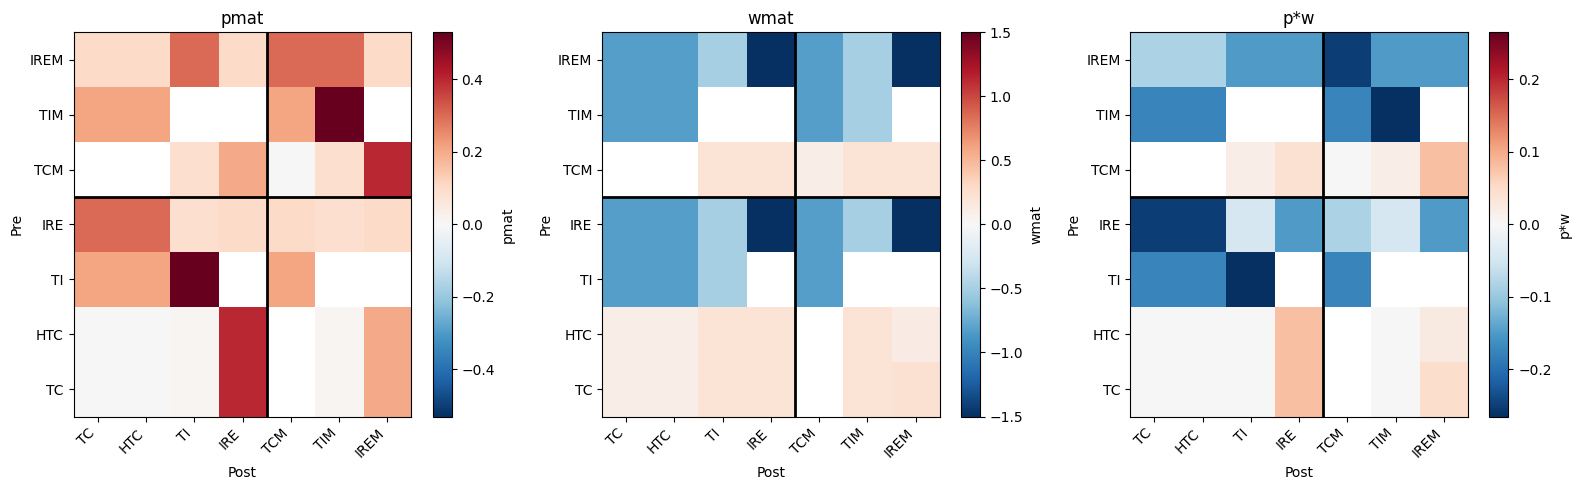

In [127]:
THAL_POPS = ['TC', 'HTC', 'TI', 'IRE', 'TCM', 'TIM', 'IREM']
CORE_POPS = ['TC', 'HTC', 'TI', 'IRE']
THAL_I_POPS = ['TI', 'TIM', 'IRE', 'IREM']

plot_conn(pops_pre=THAL_POPS, pops_post=THAL_POPS, pops_inh=THAL_I_POPS, 
          sep_x=len(CORE_POPS), sep_y=len(CORE_POPS), transpose=0)

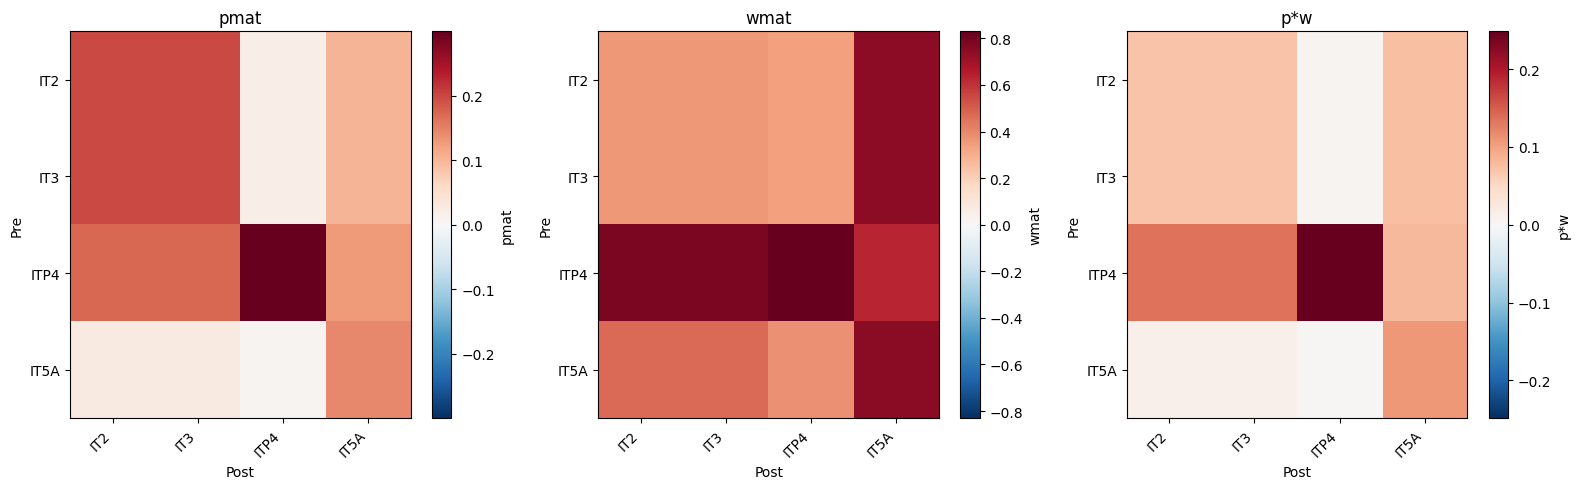

In [129]:
#plot_conn(pops_pre=['ITP4', 'IT2'], pops_post=['IT2', 'PV2', 'SOM2', 'VIP2'])
#pops = ['ITP4', 'IT2', 'PV2', 'SOM2', 'VIP2']
#pops = ['ITS4', 'ITP4', 'IT3', 'PV3', 'SOM3', 'VIP3']
pops = ['IT2', 'IT3', 'ITP4', 'IT5A']
POPS_INH = ['PV2', 'SOM2', 'VIP2', 'PV3', 'SOM3', 'VIP3']
#plot_conn(pops_pre=pops, pops_post=pops, pops_inh=POPS_INH, sep_x=2, sep_y=2, transpose=0)
plot_conn(pops_pre=pops, pops_post=pops, pops_inh=POPS_INH, transpose=0, yinv=0)

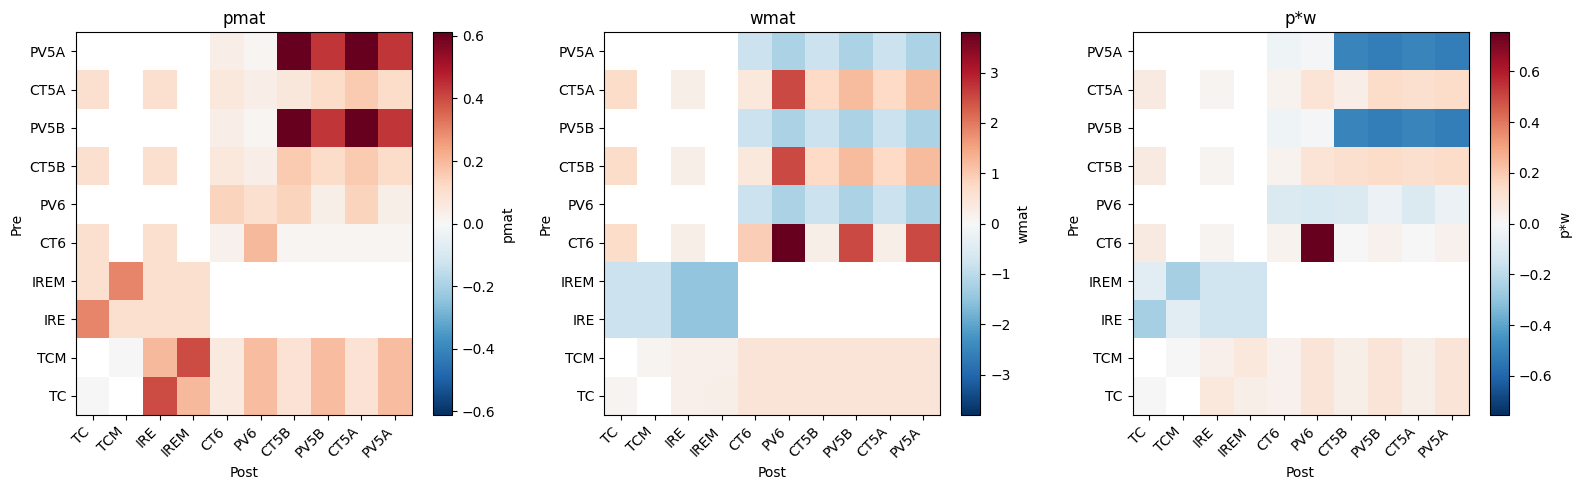

In [132]:
pops = ['TC', 'TCM', 'IRE', 'IREM', 'CT6', 'PV6', 'CT5B', 'PV5B', 'CT5A', 'PV5A']
POPS_INH = [t + l for t in ['PV', 'SOM', 'VIP', 'NGF'] 
            for l in ['2', '3', '4', '5A', '5B', '6']] + ['IRE', 'IREM']
#plot_conn(pops_pre=pops, pops_post=pops, pops_inh=POPS_INH, sep_x=2, sep_y=2, transpose=0)
plot_conn(pops_pre=pops, pops_post=pops, pops_inh=POPS_INH, transpose=0, yinv=1)

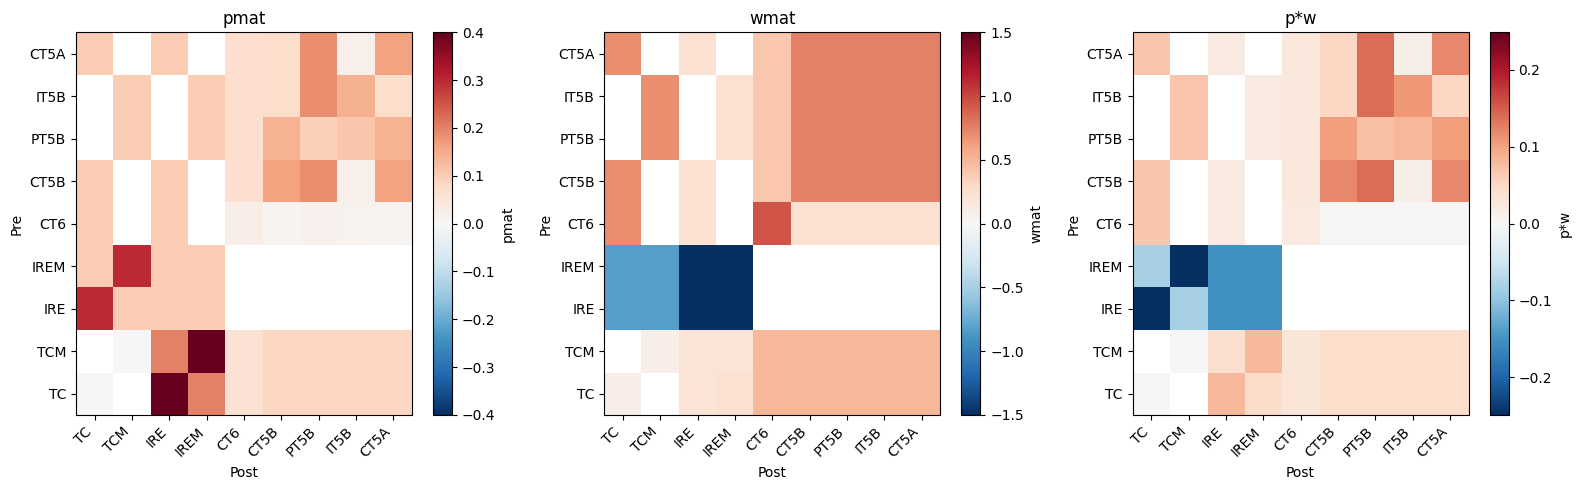

In [153]:
pops = ['TC', 'TCM', 'IRE', 'IREM', 'CT6', 'CT5B', 'PT5B', 'IT5B', 'CT5A']
POPS_INH = [t + l for t in ['PV', 'SOM', 'VIP', 'NGF'] 
            for l in ['2', '3', '4', '5A', '5B', '6']] + ['IRE', 'IREM']
#plot_conn(pops_pre=pops, pops_post=pops, pops_inh=POPS_INH, sep_x=2, sep_y=2, transpose=0)
plot_conn(pops_pre=pops, pops_post=pops, pops_inh=POPS_INH, transpose=0, yinv=1)

In [150]:
#p = C.pmat.sel(pop_post=['IRE', 'IREM'])
p = C.pmat.sel(pop_post=['TC', 'TCM', 'IRE', 'IREM', 'TI', 'TIM'])
p = p.where(p.notnull().any(dim='pop_post'), drop=True)
p

<xarray.DataArray 'pmat' (pop_post: 6, pop_pre: 12)>
array([[0.1 ,  nan,  nan, 0.1 , 0.1 , 0.  ,  nan, 0.  , 0.3 , 0.1 , 0.21,
        0.21],
       [ nan, 0.1 , 0.1 ,  nan,  nan,  nan, 0.  ,  nan, 0.1 , 0.3 , 0.21,
        0.21],
       [0.1 ,  nan,  nan, 0.1 , 0.1 , 0.4 , 0.2 , 0.4 , 0.1 , 0.1 ,  nan,
         nan],
       [ nan, 0.1 , 0.1 ,  nan,  nan, 0.2 , 0.4 , 0.2 , 0.1 , 0.1 ,  nan,
         nan],
       [0.05,  nan,  nan, 0.05, 0.05, 0.01, 0.09, 0.01, 0.09, 0.3 , 0.53,
         nan],
       [ nan, 0.05, 0.05,  nan,  nan, 0.01, 0.09, 0.01, 0.09, 0.3 ,  nan,
        0.53]])
Coordinates:
  * pop_post  (pop_post) object 'TC' 'TCM' 'IRE' 'IREM' 'TI' 'TIM'
  * pop_pre   (pop_pre) object 'CT5A' 'IT5B' 'PT5B' 'CT5B' ... 'IREM' 'TI' 'TIM'

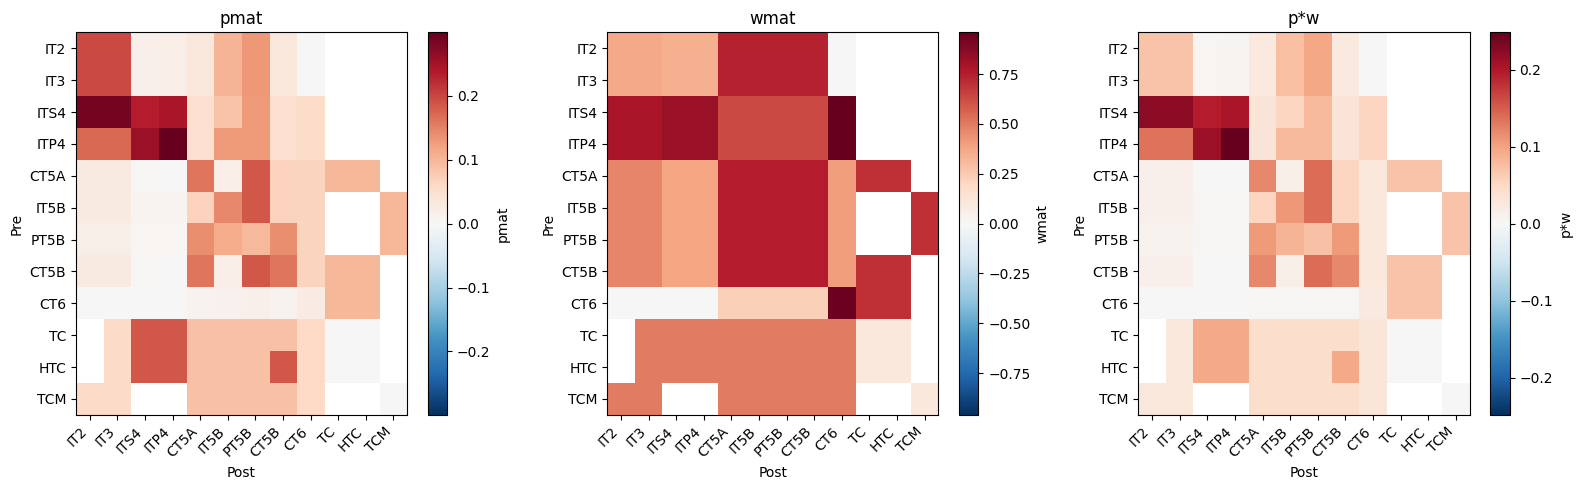

In [152]:
#pops = ['CT5A', 'IT5B', 'PT5B', 'CT5B', 'CT6', 'TC', 'TCM', 'HTC', 'IRE', 'IREM']
pops = ['IT2', 'IT3', 'ITS4', 'ITP4', 'CT5A', 'IT5B', 'PT5B', 'CT5B', 'CT6', 'TC', 'HTC', 'TCM']
plot_conn(pops_pre=pops, pops_post=pops, pops_inh=POPS_INH, transpose=0, yinv=0)